# Raster / PSTH by value latent for opto-tagged units

Generates per-unit **rasters + quantile PSTH** (same style as `plot_raster copy` /
`raster_worker.process_session`) binned by the **`QLearning_L1F1_CK1_softmax`** value
latents, but restricted to the **opto-tagged units** selected in
`save_tagged_unit_figures.ipynb`.

Pipeline:
1. **Tagged units** — read the saved opto-tagging metrics CSV and re-run
   `select_tagged_units` (standalone) to get the tagged unit ids for the target condition.
2. **Session resources** — load the Zarr PSTH, behavior-summary CSV and trial ids
   (same file conventions as `raster_worker`).
3. **Plot** — for each value latent, call `plot_raster_and_quantile_psth_by_latent`
   with `unit_ids = tagged_units`.

The opto-tagging `unit_id` (index into the NWB units table) matches the Zarr
`unit_index`, so tagged ids can be passed straight through as `unit_ids`.

In [ ]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

In [ ]:
# =============================================================================
# 2. CONFIG
# =============================================================================
from pathlib import Path

# --- Session identifiers -----------------------------------------------------
# session_date : short NWB/opto-tagging session id (matches the metrics CSV name).
# ephys_session: full sorted folder name used by the PSTH/behavior pipeline.
#                Leave as None to auto-discover it from the PSTH Zarr in step 4.
session_date = '863973_2026-08-25_14-18-29'
ephys_session = None

# --- Paths (match raster_worker.py conventions) ------------------------------
PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")
metrics_csv_path = f"/root/capsule/scratch/opto_tagging/metrics_{session_date}.csv"
OUTDIR = Path(f"/root/capsule/scratch/raster_plot_tagged/{session_date}")

# --- Value latents for the QLearning_L1F1_CK1_softmax model ------------------
# (column name in the behavior summary, colorbar label). Missing columns are
# skipped automatically in step 5.
MODEL = "QLearning_L1F1_CK1_softmax"
VALUE_LATENTS = [
    (f"{MODEL}-RPE",       "RPE (reward prediction error)"),
    (f"{MODEL}-sumQ-1",    "sumQ (total value)"),
    (f"{MODEL}-deltaQ-1",  "deltaQ (value difference)"),
    (f"{MODEL}-chosenQ-1", "chosenQ (chosen value)"),
    (f"{MODEL}-sumQ",      "sumQ current (total value)"),
    (f"{MODEL}-deltaQ",    "deltaQ current (value difference)"),
]

# --- Behavioral-state latent: smoothed response rate -------------------------
# Rolling fraction of trials with a response (animal_response != 2), used as a
# continuous latent for the raster (see step 5b). Window is measured in trials.
RESPONSE_RATE_WINDOW = 20     # sliding-window size in trials
RESPONSE_RATE_CENTER = True   # True = centered smoothing, False = causal/trailing

# --- Raster / PSTH alignment -------------------------------------------------
ALIGN_TO = "go_cue"
TIME_WIN = (-3, 4)

# --- Opto-tag condition + selection (must match save_tagged_unit_figures) ----
#   (target_power, location_tag, laser_name, cycle_duration, frequency, pulse_duration)
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.05)
SELECT_PULSE_INDEX = -1   # -1 = pooled over all pulses in the train

print(f"Metrics CSV : {metrics_csv_path}")
print(f"Output dir  : {OUTDIR}")
print(f"Value latents: {[c for c, _ in VALUE_LATENTS]}")

In [ ]:
# =============================================================================
# 3. TAGGED UNITS (re-select from the saved opto-tagging metrics CSV)
# =============================================================================
# compute_tagging_metrics only ran on QC-passing units, so every unit_id in the
# metrics table already passed QC -> selecting tagged==True is sufficient.
import re
import pandas as pd
from ast import literal_eval
from optical_tagging import select_tagged_units

metrics_df = pd.read_csv(metrics_csv_path)

tagged_df = select_tagged_units(
    metrics_df,
    alpha=0.05,
    effect_ratio=2.0,
    min_abs_increase=0.0,
    min_reliability=0.2,
    max_latency=0.006,
    max_jitter=0.003,
    correction="fdr_bh",
)

# `condition` is a string after the CSV round-trip. Older CSVs may contain numpy
# scalar wrappers like "np.float64(1.0)"; strip them before parsing.
def as_tuple(c):
    if isinstance(c, str):
        c = re.sub(r"np\.\w+\(([^()]*)\)", r"\1", c)
        try:
            c = literal_eval(c)
        except (ValueError, SyntaxError):
            return None
    return tuple(c) if isinstance(c, (tuple, list)) else None

# Match the condition on every field EXCEPT laser_name (index 2).
IGNORE_IDX = 2
match_idx = [i for i in range(6) if i != IGNORE_IDX]

def matches_ignore_laser(c):
    c = as_tuple(c)
    if c is None or len(c) != 6:
        return False
    return all(c[i] == target_cond[i] for i in match_idx)

cond_mask = tagged_df["condition"].apply(matches_ignore_laser)
pulse_mask = tagged_df["pulse_index"] == SELECT_PULSE_INDEX
sigrows = tagged_df[cond_mask & pulse_mask & (tagged_df["tagged"] == True)]

tagged_units = sorted(int(u) for u in sigrows["unit_id"].unique())
print(f"Condition (laser_name ignored): {target_cond} | pulse_index={SELECT_PULSE_INDEX}")
print(f"Tagged units ({len(tagged_units)}): {tagged_units}")
if not tagged_units:
    raise ValueError(
        "No tagged units found for this condition/selection. "
        "Check that target_cond matches a condition present in the metrics CSV."
    )

In [ ]:
# =============================================================================
# 4. LOAD SESSION RESOURCES (Zarr PSTH, behavior summary, trials)
# =============================================================================
import numpy as np
from general_utils import smart_read_csv
from behavior_utils import find_trials, get_fitted_model_names
from nwb_utils import NWBUtils
from create_psth import load_zarr

# Auto-discover the full sorted session name from the PSTH Zarr if not set.
if ephys_session is None:
    cands = sorted(PSTH_DIR.glob(f"ecephys_{session_date}_sorted*_0.2s.zarr"))
    if not cands:
        raise FileNotFoundError(
            f"No PSTH Zarr matching ecephys_{session_date}_sorted*_0.2s.zarr in {PSTH_DIR}"
        )
    ephys_session = cands[0].name[: -len("_0.2s.zarr")]
print(f"ephys_session: {ephys_session}")

zarr_path = PSTH_DIR / f"{ephys_session}_0.2s.zarr"
beh_csv = RESULTS_DIR / f"behavior_summary-{ephys_session}.csv"
assert zarr_path.exists(), f"Zarr not found: {zarr_path}"
assert beh_csv.exists(), f"Behavior CSV not found: {beh_csv}"

print(f"Fitted models: {get_fitted_model_names(session_name=ephys_session)}")

nwb, _ = NWBUtils.combine_nwb(session_name=ephys_session)
psth = load_zarr(str(zarr_path))
beh = smart_read_csv(str(beh_csv))
trials = np.asarray(find_trials(nwb, "response"))
print(f"n_trials (response): {len(trials)}")

# Optogenetics (laser-on) trials -> excluded from the raster/PSTH by default.
if "laser_on_trial" in nwb.trials.colnames:
    laser_on = np.asarray(nwb.trials["laser_on_trial"][:])
    opto_trial_ids = np.where(laser_on == 1)[0].astype(np.int64)
else:
    opto_trial_ids = np.array([], dtype=np.int64)
print(f"opto (laser-on) trials: {len(opto_trial_ids)}")

In [ ]:
# =============================================================================
# 5. PLOT RASTER + QUANTILE PSTH BY VALUE LATENT (tagged units only)
# =============================================================================
import matplotlib.pyplot as plt
from plot_raster import plot_raster_and_quantile_psth_by_latent

def _as_1d_float_array(x):
    arr = np.asarray(x, dtype=np.float32)
    return arr if arr.ndim == 1 else arr.reshape(-1)

OUTDIR.mkdir(parents=True, exist_ok=True)
n_trials = int(len(trials))

for col, lname in VALUE_LATENTS:
    if col not in beh.columns:
        print(f"skip: {col} (missing column)")
        continue
    vals = _as_1d_float_array(beh.at[0, col])
    if vals.shape[0] != n_trials:
        print(f"skip: {col} (length {vals.shape[0]} != trials {n_trials})")
        continue

    try:
        plot_raster_and_quantile_psth_by_latent(
            source=psth,
            latent_values=vals,
            latent_trial_ids=trials,
            unit_ids=tagged_units,          # restrict to opto-tagged units
            exclude_trial_ids=opto_trial_ids,  # drop laser-on trials (default on)
            align_to_event=ALIGN_TO,
            time_window=TIME_WIN,
            n_bins=4,
            binning="equal",
            quantile_stat="mean",
            ci="sem",
            title_prefix="",
            figsize=(6, 5),
            save_path=str(OUTDIR),
            cmap_name="coolwarm",
            raster_colormap=False,          # continuous latent -> black rasters
            show_colormap=True,
            save_prefix=f"{col}_",
            latent_name=lname,
            show=False,
            overwrite=True,
            min_trial_rate=1,
            save_format=["png"],
        )
        print(f"plotted: {col} for {len(tagged_units)} tagged units -> {OUTDIR}")
    except Exception as e:
        print(f"error plotting {col}: {e}")
    finally:
        plt.close("all")

print("Done.")

### 5b. Raster + quantile PSTH by smoothed response rate

Uses a *behavioral-state* latent instead of a model value: the running
**response rate** = fraction of trials with a response (`animal_response != 2`),
smoothed over a sliding window of `RESPONSE_RATE_WINDOW` trials. This is
computed over **all** trials (so low-engagement epochs are represented), then
fed to the same `plot_raster_and_quantile_psth_by_latent` machinery. Opto
(laser-on) trials are excluded by default.

In [ ]:
# =============================================================================
# 5b. PLOT RASTER + QUANTILE PSTH BY SMOOTHED RESPONSE RATE (behavioral state)
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
from plot_raster import plot_raster_and_quantile_psth_by_latent

# Per-trial responded flag over ALL trials (1 = responded, 0 = no-response).
_resp_all = np.asarray(nwb.trials["animal_response"][:])
responded = (_resp_all != 2).astype(np.float32)
all_trial_ids = np.arange(responded.shape[0], dtype=np.int64)

# Running response rate: rolling fraction responded over a sliding trial window.
response_rate = (
    pd.Series(responded)
    .rolling(window=RESPONSE_RATE_WINDOW, min_periods=1, center=RESPONSE_RATE_CENTER)
    .mean()
    .to_numpy()
    .astype(np.float32)
)

_mode = "centered" if RESPONSE_RATE_CENTER else "causal"
rr_label = f"response rate ({RESPONSE_RATE_WINDOW}-trial {_mode})"
print(
    f"response rate: n_trials={responded.size}, "
    f"range=[{np.nanmin(response_rate):.2f}, {np.nanmax(response_rate):.2f}], "
    f"mean={np.nanmean(response_rate):.2f}"
)

OUTDIR.mkdir(parents=True, exist_ok=True)
try:
    plot_raster_and_quantile_psth_by_latent(
        source=psth,
        latent_values=response_rate,
        latent_trial_ids=all_trial_ids,
        unit_ids=tagged_units,              # restrict to opto-tagged units
        exclude_trial_ids=opto_trial_ids,   # drop laser-on trials (default on)
        align_to_event=ALIGN_TO,
        time_window=TIME_WIN,
        n_bins=4,
        binning="equal",
        quantile_stat="mean",
        ci="sem",
        title_prefix="",
        figsize=(6, 5),
        save_path=str(OUTDIR),
        cmap_name="viridis",
        raster_colormap=False,              # continuous latent -> black rasters
        show_colormap=True,
        save_prefix="response_rate_",
        latent_name=rr_label,
        show=False,
        overwrite=True,
        min_trial_rate=1,
        save_format=["png"],
    )
    print(f"plotted: response rate for {len(tagged_units)} tagged units -> {OUTDIR}")
except Exception as e:
    print(f"error plotting response rate: {e}")
finally:
    plt.close("all")

### 5c. Combined-units quantile PSTH by smoothed response rate

Same response-rate binning as 5b, but **pooled across all tagged units**: trials
are split into `N_BINS_RR` response-rate bins, and within each bin the PSTH is
averaged over trials and over units (shaded band = SEM across units). One figure,
one line per response-rate bin. Opto (laser-on) trials are excluded.

In [ ]:
# =============================================================================
# 5c. COMBINED-UNITS QUANTILE PSTH BY SMOOTHED RESPONSE RATE
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from create_psth import load_psth_raster_subset

N_BINS_RR = 4          # number of response-rate bins
BINNING_RR = "equal"   # "equal" (linear) or "quantile" (equal-count) edges

# Ensure the response-rate latent from 5b is available (recompute if needed).
if "response_rate" not in globals():
    import pandas as pd
    _resp_all = np.asarray(nwb.trials["animal_response"][:])
    responded = (_resp_all != 2).astype(np.float32)
    all_trial_ids = np.arange(responded.shape[0], dtype=np.int64)
    response_rate = (
        pd.Series(responded)
        .rolling(window=RESPONSE_RATE_WINDOW, min_periods=1, center=RESPONSE_RATE_CENTER)
        .mean().to_numpy().astype(np.float32)
    )
_mode = "centered" if RESPONSE_RATE_CENTER else "causal"
rr_label = f"response rate ({RESPONSE_RATE_WINDOW}-trial {_mode})"

# Population PSTH for tagged units across all trials.
pop_psth, _ = load_psth_raster_subset(
    psth, trial_ids=None, unit_ids=tagged_units,
    align_to_event=ALIGN_TO, time_window=TIME_WIN, consolidated=True,
)
trial_dim = next(d for d in pop_psth.dims if d.startswith("trial_"))
trial_coord = next(c for c in pop_psth.coords if c.startswith("trial_index_"))
times = pop_psth.coords["time"].values
avail_ids = np.asarray(pop_psth.coords[trial_coord].values, dtype=np.int64)
n_units = int(pop_psth.sizes["unit"])

# Map response rate onto available trials; drop opto and NaN.
id_to_rr = {int(t): float(r) for t, r in zip(all_trial_ids, response_rate)}
lat_avail = np.array([id_to_rr.get(int(t), np.nan) for t in avail_ids], dtype=float)
keep = np.isfinite(lat_avail) & ~np.isin(avail_ids, opto_trial_ids)
ids_k = avail_ids[keep]
lat_k = lat_avail[keep]

# Bin edges over the response-rate latent.
if BINNING_RR == "quantile":
    edges = np.unique(np.nanpercentile(lat_k, np.linspace(0, 100, N_BINS_RR + 1)))
else:
    edges = np.linspace(float(np.nanmin(lat_k)), float(np.nanmax(lat_k)), N_BINS_RR + 1)
edges[-1] = np.nextafter(edges[-1], np.inf)
n_bins_eff = int(edges.size - 1)
bin_idx = np.clip(np.digitize(lat_k, edges[1:-1], right=False), 0, n_bins_eff - 1)

cmap = cm.get_cmap("viridis", n_bins_eff)

fig, ax = plt.subplots(figsize=(6, 4))
for b in range(n_bins_eff):
    tids = ids_k[bin_idx == b]
    if tids.size == 0:
        continue
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})          # dims: unit, trial, time
    per_unit = sub.mean(dim=trial_dim)             # dims: unit, time
    pop_mean = per_unit.mean(dim="unit").values
    pop_sem = per_unit.std(dim="unit").values / np.sqrt(max(n_units, 1))
    lo, hi = edges[b], edges[b + 1]
    ax.plot(times, pop_mean, color=cmap(b),
            label=f"[{lo:.2f}, {hi:.2f})  n_trials={tids.size}")
    ax.fill_between(times, pop_mean - pop_sem, pop_mean + pop_sem,
                    color=cmap(b), alpha=0.25)

ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel(f"Time from {ALIGN_TO} (s)")
ax.set_ylabel("Firing rate (Hz)")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if len(opto_trial_ids) else ""
ax.set_title(f"Combined {n_units} tagged units by {rr_label}{excl_note}")
ax.legend(frameon=False, title=rr_label, fontsize=8)
fig.tight_layout()

RR_COMBINED_PATH = OUTDIR / "quantile_psth_response_rate_combined_units.png"
fig.savefig(RR_COMBINED_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Combined quantile PSTH saved -> {RR_COMBINED_PATH}")

### 5d. Combined-units quantile PSTH by a selected value latent

Same pooling as 5c, but binned by a **selected value latent** (`SELECTED_LATENT`,
one of the `VALUE_LATENTS` columns) instead of the response rate. Trials are split
into `N_BINS_LAT` latent bins, and within each bin the PSTH is averaged over trials
and over tagged units (shaded band = SEM across units). One figure, one line per
latent bin. Opto (laser-on) trials are excluded.

/tmp/ipykernel_777694/202992277.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins_eff)


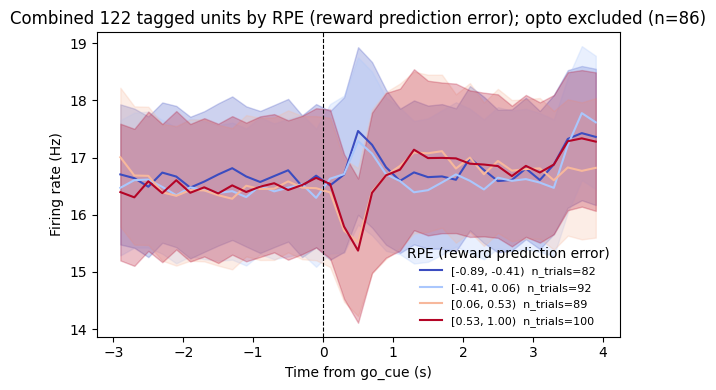

Combined quantile PSTH saved -> /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/quantile_psth_QLearning_L1F1_CK1_softmax-RPE_combined_units.png


In [60]:
# =============================================================================
# 5d. COMBINED-UNITS QUANTILE PSTH BY A SELECTED VALUE LATENT
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from create_psth import load_psth_raster_subset

# Pick which value latent to pool over (a column name from VALUE_LATENTS).
SELECTED_LATENT = f"{MODEL}-RPE"   # e.g. f"{MODEL}-sumQ-1", f"{MODEL}-deltaQ-1", ...
N_BINS_LAT = 4           # number of latent bins
BINNING_LAT = "equal"    # "equal" (linear) or "quantile" (equal-count) edges

# Human-readable label from VALUE_LATENTS (fallback to the column name).
_lat_label = dict(VALUE_LATENTS).get(SELECTED_LATENT, SELECTED_LATENT)
if SELECTED_LATENT not in beh.columns:
    raise KeyError(f"{SELECTED_LATENT!r} not in behavior-summary columns.")

# Per-trial latent values, aligned to the response trials used elsewhere.
lat_vals = np.asarray(beh.at[0, SELECTED_LATENT], dtype=np.float32).reshape(-1)
if lat_vals.shape[0] != len(trials):
    raise ValueError(
        f"{SELECTED_LATENT}: length {lat_vals.shape[0]} != n_trials {len(trials)}"
    )

# Population PSTH for tagged units across all trials.
pop_psth, _ = load_psth_raster_subset(
    psth, trial_ids=None, unit_ids=tagged_units,
    align_to_event=ALIGN_TO, time_window=TIME_WIN, consolidated=True,
)
trial_dim = next(d for d in pop_psth.dims if d.startswith("trial_"))
trial_coord = next(c for c in pop_psth.coords if c.startswith("trial_index_"))
times = pop_psth.coords["time"].values
avail_ids = np.asarray(pop_psth.coords[trial_coord].values, dtype=np.int64)
n_units = int(pop_psth.sizes["unit"])

# Map the selected latent onto available trials; drop opto and NaN.
id_to_lat = {int(t): float(v) for t, v in zip(np.asarray(trials, dtype=np.int64), lat_vals)}
lat_avail = np.array([id_to_lat.get(int(t), np.nan) for t in avail_ids], dtype=float)
keep = np.isfinite(lat_avail) & ~np.isin(avail_ids, opto_trial_ids)
ids_k = avail_ids[keep]
lat_k = lat_avail[keep]

# Bin edges over the selected latent.
if BINNING_LAT == "quantile":
    edges = np.unique(np.nanpercentile(lat_k, np.linspace(0, 100, N_BINS_LAT + 1)))
else:
    edges = np.linspace(float(np.nanmin(lat_k)), float(np.nanmax(lat_k)), N_BINS_LAT + 1)
edges[-1] = np.nextafter(edges[-1], np.inf)
n_bins_eff = int(edges.size - 1)
bin_idx = np.clip(np.digitize(lat_k, edges[1:-1], right=False), 0, n_bins_eff - 1)

cmap = cm.get_cmap("coolwarm", n_bins_eff)

fig, ax = plt.subplots(figsize=(6, 4))
for b in range(n_bins_eff):
    tids = ids_k[bin_idx == b]
    if tids.size == 0:
        continue
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})          # dims: unit, trial, time
    per_unit = sub.mean(dim=trial_dim)             # dims: unit, time
    pop_mean = per_unit.mean(dim="unit").values
    pop_sem = per_unit.std(dim="unit").values / np.sqrt(max(n_units, 1))
    lo, hi = edges[b], edges[b + 1]
    ax.plot(times, pop_mean, color=cmap(b),
            label=f"[{lo:.2f}, {hi:.2f})  n_trials={tids.size}")
    ax.fill_between(times, pop_mean - pop_sem, pop_mean + pop_sem,
                    color=cmap(b), alpha=0.25)

ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel(f"Time from {ALIGN_TO} (s)")
ax.set_ylabel("Firing rate (Hz)")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if len(opto_trial_ids) else ""
ax.set_title(f"Combined {n_units} tagged units by {_lat_label}{excl_note}")
ax.legend(frameon=False, title=_lat_label, fontsize=8)
fig.tight_layout()

_lat_fname = re.sub(r"[^0-9A-Za-z._-]", "_", SELECTED_LATENT)
LAT_COMBINED_PATH = OUTDIR / f"quantile_psth_{_lat_fname}_combined_units.png"
fig.savefig(LAT_COMBINED_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Combined quantile PSTH saved -> {LAT_COMBINED_PATH}")